# 3. FashionMNIST Dataset

In this section, the FashionMNIST dataset is loaded and prepared
for the image classification task.

FashionMNIST contains grayscale images of clothing items belonging
to 10 different classes. The dataset is divided into a training set
and a test set.

The dataset is loaded directly using
`torchvision.datasets.FashionMNIST`.


In [5]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [6]:
import sys

print("Python executable:")
print(sys.executable)

Python executable:
d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\.venv\Scripts\python.exe


In [7]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("PyTorch imported successfully!")

PyTorch version: 2.13.0+cpu
Torchvision version: 0.28.0+cpu
PyTorch imported successfully!


In [8]:
current_dir = Path.cwd()

if (current_dir / "Practice_1").exists():
    REPO_ROOT = current_dir
elif current_dir.name == "notebooks":
    REPO_ROOT = current_dir.parents[1]
else:
    REPO_ROOT = current_dir

DATA_DIR = REPO_ROOT / "data"
FIGURE_DIR = REPO_ROOT / "Practice_1" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", REPO_ROOT)
print("Dataset directory:", DATA_DIR)
print("Figure directory:", FIGURE_DIR)

Repository root: d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2
Dataset directory: d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\data
Figure directory: d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures


## 4. Data Transformation

Before the images are used by the neural network, they are converted
to PyTorch tensors using `transforms.ToTensor()`.

This transformation converts the image data into a tensor representation
that can be processed by PyTorch.

In [9]:
transform = transforms.Compose([
    transforms.ToTensor()
])

print(transform)

Compose(
    ToTensor()
)


In [10]:
# Use the official FashionMNIST GitHub repository as a download mirror
datasets.FashionMNIST.mirrors = [
    "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
]

print("FashionMNIST mirror updated.")

FashionMNIST mirror updated.


In [11]:
train_dataset = datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=False,
    download=True,
    transform=transform
)

print("FashionMNIST loaded successfully!")

FashionMNIST loaded successfully!


In [12]:
print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))

image, label = train_dataset[0]

print("\nFirst sample")
print("Image shape:", image.shape)
print("Label:", label)
print("Data type:", image.dtype)
print("Minimum pixel value:", image.min().item())
print("Maximum pixel value:", image.max().item())

Number of training samples: 60000
Number of test samples: 10000

First sample
Image shape: torch.Size([1, 28, 28])
Label: 9
Data type: torch.float32
Minimum pixel value: 0.0
Maximum pixel value: 1.0


### Observation

The dataset was loaded successfully.

Each image is represented as a PyTorch tensor with one grayscale
channel. The image dimensions are suitable for use as input to the
neural network.

After `ToTensor()`, the image values are represented as floating-point
values suitable for PyTorch computations.

In [13]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


## 5. Creating DataLoaders

PyTorch `DataLoader` is used to divide the dataset into mini-batches.

For the training dataset, `shuffle=True` is used so that the samples
are presented in a different order during training.

For the test dataset, `shuffle=False` is used because the test set
is only used for model evaluation.

In [14]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training DataLoader created.")
print("Test DataLoader created.")
print("Batch size:", BATCH_SIZE)

Training DataLoader created.
Test DataLoader created.
Batch size: 64


In [15]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


### Batch Inspection

A mini-batch was extracted from the training DataLoader to verify
the data structure.

The image tensor follows the format:

`[batch_size, channels, height, width]`

The label tensor contains the class labels corresponding to the
images in the batch.

Mini-batch training allows the neural network to process a subset
of the training data during each optimization step.

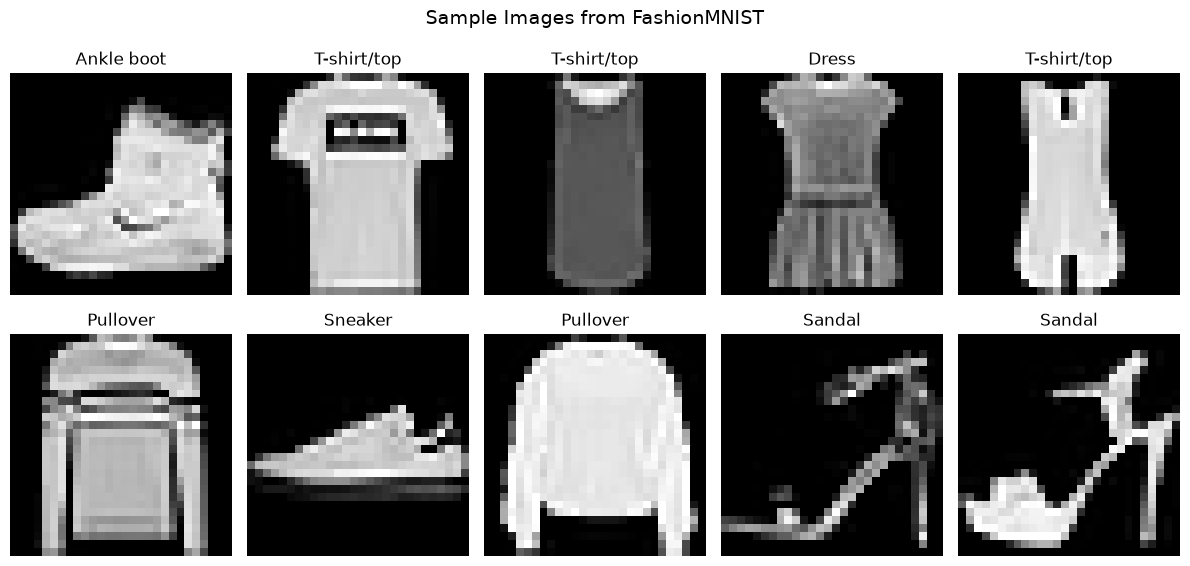

Figure saved to: d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\dataset_samples.png


In [16]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")

plt.suptitle(
    "Sample Images from FashionMNIST",
    fontsize=14
)

plt.tight_layout()

output_path = FIGURE_DIR / "dataset_samples.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", output_path)

### Dataset Visualization Analysis

The visualization shows representative samples from different
FashionMNIST classes.

The images are grayscale and have relatively low resolution.
Although several clothing categories can be easily distinguished,
some classes have similar shapes, which may make classification
more challenging for the neural network.

The visualization also confirms that the images and labels were
loaded correctly before model training.

## 5. DataLoader

PyTorch `DataLoader` is used to divide the dataset into mini-batches
for efficient neural network training.

For the training dataset, `shuffle=True` is used to shuffle the samples
before each training epoch.

For the test dataset, `shuffle=False` is used because the test data
is only used for model evaluation.

In [17]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train DataLoader created successfully.")
print("Test DataLoader created successfully.")
print("Batch size:", BATCH_SIZE)

Train DataLoader created successfully.
Test DataLoader created successfully.
Batch size: 64


In [18]:
print("Number of training batches:", len(train_loader))
print("Number of test batches:", len(test_loader))

Number of training batches: 938
Number of test batches: 157


In [19]:
images, labels = next(iter(train_loader))

print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)

Images batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


In [20]:
for i in range(10):
    label_index = labels[i].item()
    print(
        f"Sample {i + 1}: "
        f"Label = {label_index}, "
        f"Class = {class_names[label_index]}"
    )

Sample 1: Label = 1, Class = Trouser
Sample 2: Label = 6, Class = Shirt
Sample 3: Label = 5, Class = Sandal
Sample 4: Label = 6, Class = Shirt
Sample 5: Label = 8, Class = Bag
Sample 6: Label = 2, Class = Pullover
Sample 7: Label = 6, Class = Shirt
Sample 8: Label = 9, Class = Ankle boot
Sample 9: Label = 1, Class = Trouser
Sample 10: Label = 1, Class = Trouser


### DataLoader Analysis

The training and test datasets were successfully converted into
PyTorch DataLoaders.

A batch size of 64 was selected, meaning that up to 64 images are
processed during each training iteration.

The training DataLoader uses `shuffle=True` so that the ordering of
training samples changes between epochs. This helps prevent the model
from learning patterns related to a fixed data order.

The test DataLoader uses `shuffle=False` because the test dataset is
only used for evaluation.

The image batch follows the format:

`[batch_size, channels, height, width]`

and the corresponding label tensor contains one class label for each
image.